# EDA 00 — Data Profile & Missing Values

First pass over the **train split**: shape, dtypes, statistics, missing-value landscape, cardinality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = pd.read_parquet(DataLoader.processed('train.parquet'))
print('Train shape:', df.shape)

Train shape: (137176, 26)


## 1 · Data types & overview

In [2]:
dtype_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'null_pct': (df.isna().sum() / len(df) * 100).round(2),
    'nunique': df.nunique(),
    'sample_value': df.iloc[0].astype(str)
})
dtype_summary

,dtype,non_null,null,null_pct,nunique,sample_value
Inspection ID,int64,137176,0,0.00,137176,67738
DBA Name,object,137176,0,0.00,20773,MICHAEL'S ON MAIN CAFE
AKA Name,object,135506,1670,1.22,19826,MICHAEL'S ON MAIN CAFE
License #,float64,137162,14,0.01,28152,2008948.0
Facility Type,object,136563,613,0.45,431,Restaurant
Risk,object,137176,0,0.00,4,High
Address,object,137174,2,0.00,15766,8750 W BRYN WAWR AVE
Zip,float64,137148,28,0.02,100,60631.0
Inspection Date,datetime64[ns],137176,0,0.00,1939,2010-01-04 00:00:00
Inspection Type,object,137175,1,0.00,103,License


## 2 · Descriptive statistics

In [3]:
print('── Numeric columns ──')
display(df.describe())
print('\n── Categorical / object columns ──')
df.describe(include=['object', 'string', 'bool'])

── Numeric columns ──


,Inspection ID,License #,Zip,Inspection Date,Latitude,Longitude
count,1.371760e+05,1.371620e+05,137148.000000,137176,136683.000000,136683.000000
mean,1.231919e+06,1.515238e+06,60628.831984,2013-12-07 11:37:54.800256512,41.879723,-87.675998
min,4.424700e+04,0.000000e+00,60007.000000,2010-01-04 00:00:00,41.644670,-87.914428
25%,6.342818e+05,1.120021e+06,60614.000000,2011-12-12 00:00:00,41.830784,-87.707209
50%,1.361258e+06,1.922899e+06,60625.000000,2014-01-15 00:00:00,41.890970,-87.665585
75%,1.584046e+06,2.158449e+06,60643.000000,2015-11-23 00:00:00,41.938951,-87.634299
max,2.240469e+06,9.999999e+06,60827.000000,2017-08-30 00:00:00,42.021064,-87.525094
std,5.766182e+05,8.875598e+05,22.765592,NaN,0.080764,0.059223



── Categorical / object columns ──


,DBA Name,AKA Name,Facility Type,Risk,Address,Inspection Type,Results,Violations,COMMUNITY AREA NAME,LICENSE DESCRIPTION,APPLICATION TYPE,LICENSE TERM START DATE,LICENSE TERM EXPIRATION DATE,LICENSE STATUS,flag_non_il_state,flag_non_chicago_city,flag_longitude_outside_typical_range,violations_recorded,license_matched,has_prior_inspection
count,137176,135506,136563,137176,137174,137175,137176,114101,129043,130411,130411,19689,130395,130411,137176,137176,137176,137176,137176,137176
unique,20773,19826,431,4,15766,103,3,113479,77,63,6,1455,317,4,1,2,1,2,1,2
top,SUBWAY,SUBWAY,Restaurant,High,11601 W TOUHY AVE,Canvass,Pass,32. FOOD AND NON-FOOD CONTACT SURFACES PROPERL...,NEAR NORTH SIDE,Retail Food Establishment,RENEW,2013-09-16,2021-07-15,AAI,False,False,False,True,False,True
freq,2174,2656,92150,99437,1787,66377,91990,10,10881,113144,118429,276,6081,100330,137176,137027,137176,114101,137176,110027


## 3 · Missing values

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]
print(f'Columns with missing values: {len(missing_df)} / {df.shape[1]}')
missing_df

Columns with missing values: 15 / 26


,count,pct
LICENSE TERM START DATE,117487,85.65
Violations,23075,16.82
COMMUNITY AREA NAME,8133,5.93
LICENSE TERM EXPIRATION DATE,6781,4.94
LICENSE DESCRIPTION,6765,4.93
APPLICATION TYPE,6765,4.93
LICENSE STATUS,6765,4.93
AKA Name,1670,1.22
Facility Type,613,0.45
Latitude,493,0.36


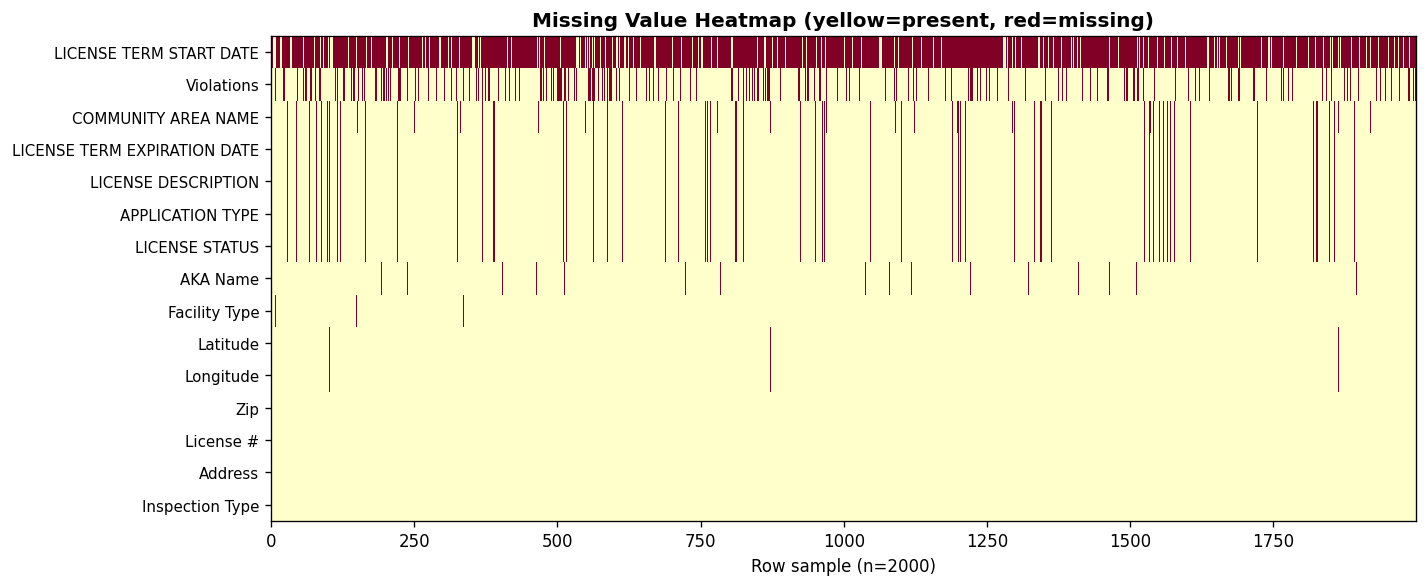

In [5]:
# Missing-value heatmap (sampled for performance)
sample_size = min(2000, len(df))
rng = np.random.default_rng(42)
sample_idx = np.sort(rng.choice(len(df), sample_size, replace=False))
cols_with_missing = missing_df.index.tolist()

if cols_with_missing:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(df.iloc[sample_idx][cols_with_missing].isna().values.T,
              aspect='auto', cmap='YlOrRd', interpolation='none')
    ax.set_yticks(range(len(cols_with_missing)))
    ax.set_yticklabels(cols_with_missing, fontsize=9)
    ax.set_xlabel(f'Row sample (n={sample_size})')
    ax.set_title('Missing Value Heatmap (yellow=present, red=missing)', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4 · Cardinality report

High-cardinality categoricals need target/frequency encoding; low-cardinality ones can be one-hot encoded.

In [6]:
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
bool_cols = df.select_dtypes(include='bool').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

cardinality = pd.DataFrame({
    'dtype': df[cat_cols].dtypes.astype(str),
    'nunique': df[cat_cols].nunique(),
    'null_pct': (df[cat_cols].isna().sum() / len(df) * 100).round(2),
    'top_value': [df[c].mode().iloc[0] if not df[c].mode().empty else 'N/A' for c in cat_cols],
}).sort_values('nunique', ascending=False)

print(f'Categorical: {len(cat_cols)}  |  Boolean: {len(bool_cols)} {bool_cols}  |  Numeric: {len(num_cols)} {num_cols}')
cardinality

Categorical: 14  |  Boolean: 6 ['flag_non_il_state', 'flag_non_chicago_city', 'flag_longitude_outside_typical_range', 'violations_recorded', 'license_matched', 'has_prior_inspection']  |  Numeric: 5 ['Inspection ID', 'License #', 'Zip', 'Latitude', 'Longitude']


,dtype,nunique,null_pct,top_value
Violations,object,113479,16.82,"30. FOOD IN ORIGINAL CONTAINER, PROPERLY LABEL..."
DBA Name,object,20773,0.00,SUBWAY
AKA Name,object,19826,1.22,SUBWAY
Address,object,15766,0.00,11601 W TOUHY AVE
LICENSE TERM START DATE,object,1455,85.65,2013-09-16
Facility Type,object,431,0.45,Restaurant
LICENSE TERM EXPIRATION DATE,object,317,4.94,2021-07-15
Inspection Type,object,103,0.00,Canvass
COMMUNITY AREA NAME,object,77,5.93,NEAR NORTH SIDE
LICENSE DESCRIPTION,object,63,4.93,Retail Food Establishment


## 5 · Memory usage

In [7]:
mem = df.memory_usage(deep=True)
print(f'Total memory: {mem.sum() / 1e6:.1f} MB')
print('\nTop 10 columns by memory:')
(mem.drop('Index') / 1e6).sort_values(ascending=False).head(10).round(2)

Total memory: 252.1 MB

Top 10 columns by memory:


Violations                      142.13
LICENSE DESCRIPTION               9.88
DBA Name                          9.29
Address                           9.13
AKA Name                          9.12
Inspection Type                   8.24
Facility Type                     8.21
COMMUNITY AREA NAME               7.93
LICENSE TERM EXPIRATION DATE      7.86
Results                           7.48
dtype: float64